In [ ]:
!pip install pyspark --quite
print("pyspark instalado correctamente")


Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

no such option: --quite
pyspark instalado correctamente


In [ ]:
from pyspark import sql
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import IntegerType, FloatType, StringType
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

spark= SparkSession.builder \
  .appName('Analisis_Goles_copas_del_mundo') \
  .config('spark.sql.repl.eagerEval.enabled', True) \
  .getOrCreate()

spark.sparkContext.setLogLevel('ERROR')
print(f'Spark version: {spark.version}')
print('SparkSession Creada exitosamente')


Spark version: 4.0.2
SparkSession Creada exitosamente


In [ ]:
from os import path
!pip install kagglehub --quite

import kagglehub

path= kagglehub.dataset_download("anairamcosta/worldcupmatches")

print('Archivos descargados en:', path)

import os
for archivo in os.listdir(path):
  print(' -',archivo)


Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

no such option: --quite


100%|██████████| 35.8k/35.8k [00:00<00:00, 5.97MB/s]

Extracting files...
Archivos descargados en: /root/.cache/kagglehub/datasets/anairamcosta/worldcupmatches/versions/1
 - WorldCupMatches.csv


In [ ]:
import os

ruta_cvs = None
for archivo in os.listdir(path):
  if archivo.endswith('.csv'):
    ruta_cvs = os.path.join(path, archivo)
    print(f'cvs encontrado en: {ruta_cvs}')

  df = spark.read.csv(
      ruta_cvs,
      header=True,
      inferSchema=True
  )

  print(f'Total de filas: {df.count()}')
  print(f'Total de columnas: {len(df.columns)}')
  df.show(5, truncate=False)

cvs encontrado en: /root/.cache/kagglehub/datasets/anairamcosta/worldcupmatches/versions/1/WorldCupMatches.csv
Total de filas: 836
Total de columnas: 20
+----+--------------------+-------+--------------+-----------+------------+-------------+-------------+------------+-------------+----------+-----------------+-----------------+----------------------+------------------------+--------------------------+-------+-------+----------------+----------------+
|Year|Datetime            |Stage  |Stadium       |City       |HomeTeamName|HomeTeamGoals|AwayTeamGoals|AwayTeamName|WinConditions|Attendance|HalfTimeHomeGoals|HalfTimeAwayGoals|Referee               |Assistant1              |Assistant2                |RoundID|MatchID|HomeTeamInitials|AwayTeamInitials|
+----+--------------------+-------+--------------+-----------+------------+-------------+-------------+------------+-------------+----------+-----------------+-----------------+----------------------+------------------------+----------------

In [ ]:
print ( '=== esquema del dataset ===')
df.printSchema()

print(' === primeras 5 filas ===')
df.show(5, truncate=False)


=== esquema del dataset ===
root
 |-- Year: integer (nullable = true)
 |-- Datetime: string (nullable = true)
 |-- Stage: string (nullable = true)
 |-- Stadium: string (nullable = true)
 |-- City: string (nullable = true)
 |-- HomeTeamName: string (nullable = true)
 |-- HomeTeamGoals: integer (nullable = true)
 |-- AwayTeamGoals: integer (nullable = true)
 |-- AwayTeamName: string (nullable = true)
 |-- WinConditions: string (nullable = true)
 |-- Attendance: double (nullable = true)
 |-- HalfTimeHomeGoals: integer (nullable = true)
 |-- HalfTimeAwayGoals: integer (nullable = true)
 |-- Referee: string (nullable = true)
 |-- Assistant1: string (nullable = true)
 |-- Assistant2: string (nullable = true)
 |-- RoundID: integer (nullable = true)
 |-- MatchID: integer (nullable = true)
 |-- HomeTeamInitials: string (nullable = true)
 |-- AwayTeamInitials: string (nullable = true)

 === primeras 5 filas ===
+----+--------------------+-------+--------------+-----------+------------+----------

In [ ]:
print('=== Limpieza de datos ===')

print('\nValores nulos por columna:')
df.select([
    F.count(F.when(F.isnull(c), c)).alias(c)
    for c in df.columns
]).show()

df_clean = df.dropna(subset=[
    'Year', 'HomeTeamName', 'AwayTeamName',
    'HomeTeamGoals', 'AwayTeamGoals'
])

df_clean = df_clean.dropDuplicates()

df_clean = df_clean \
  .withColumnRenamed('HomeTeamName', 'Local') \
  .withColumnRenamed('AwayTeamName', 'Visitante') \
  .withColumnRenamed('HomeTeamGoals', 'Goles_Local') \
  .withColumnRenamed('AwayTeamGoals', 'Goles_Visitante') \
  .withColumnRenamed('Year', 'Año') \
  .withColumnRenamed('Stage', 'Fase') \
  .withColumnRenamed('City', 'Ciudad') \
  .withColumnRenamed('Attendance', 'Asistencia')

df_clean = df_clean \
  .withColumn('goles_local', F.col('Goles_Local').cast(IntegerType())) \
  .withColumn('goles_visitante', F.col('Goles_Visitante').cast(IntegerType())) \
  .withColumn('año', F.col('Año').cast(IntegerType()))

print(f'Filas después de limpieza: {df_clean.count()}')
print('Limpieza completada exitosamente ✅')


=== Limpieza de datos ===

Valores nulos por columna:
+----+--------+-----+-------+----+------------+-------------+-------------+------------+-------------+----------+-----------------+-----------------+-------+----------+----------+-------+-------+----------------+----------------+
|Year|Datetime|Stage|Stadium|City|HomeTeamName|HomeTeamGoals|AwayTeamGoals|AwayTeamName|WinConditions|Attendance|HalfTimeHomeGoals|HalfTimeAwayGoals|Referee|Assistant1|Assistant2|RoundID|MatchID|HomeTeamInitials|AwayTeamInitials|
+----+--------+-----+-------+----+------------+-------------+-------------+------------+-------------+----------+-----------------+-----------------+-------+----------+----------+-------+-------+----------------+----------------+
|   0|       0|    0|      0|   0|           0|            0|            0|           0|            0|         0|                0|                0|      0|         0|         0|      0|      0|               0|               0|
+----+--------+-----+-----

In [ ]:
print(' *** ANALISIS EXPLORATORIO DE DATOS (EDA) ***')

print ('\n --- estadisticas generales de goles --- ')
df_clean.select('goles_local', 'goles_visitante').describe().show()

print ('\n --- total de partidos por año --- ')
df_clean.groupBy('año').count().orderBy('año').show()


 *** ANALISIS EXPLORATORIO DE DATOS (EDA) ***

 --- estadisticas generales de goles --- 
+-------+------------------+------------------+
|summary|       goles_local|   goles_visitante|
+-------+------------------+------------------+
|  count|               836|               836|
|   mean|1.8241626794258374|1.0215311004784688|
| stddev|1.6191784395219355| 1.072024465821105|
|    min|                 0|                 0|
|    max|                10|                 7|
+-------+------------------+------------------+


 --- total de partidos por año --- 
+----+-----+
| año|count|
+----+-----+
|1930|   18|
|1934|   17|
|1938|   18|
|1950|   22|
|1954|   26|
|1958|   35|
|1962|   32|
|1966|   32|
|1970|   32|
|1974|   38|
|1978|   38|
|1982|   52|
|1986|   52|
|1990|   52|
|1994|   52|
|1998|   64|
|2002|   64|
|2006|   64|
|2010|   64|
|2014|   64|
+----+-----+



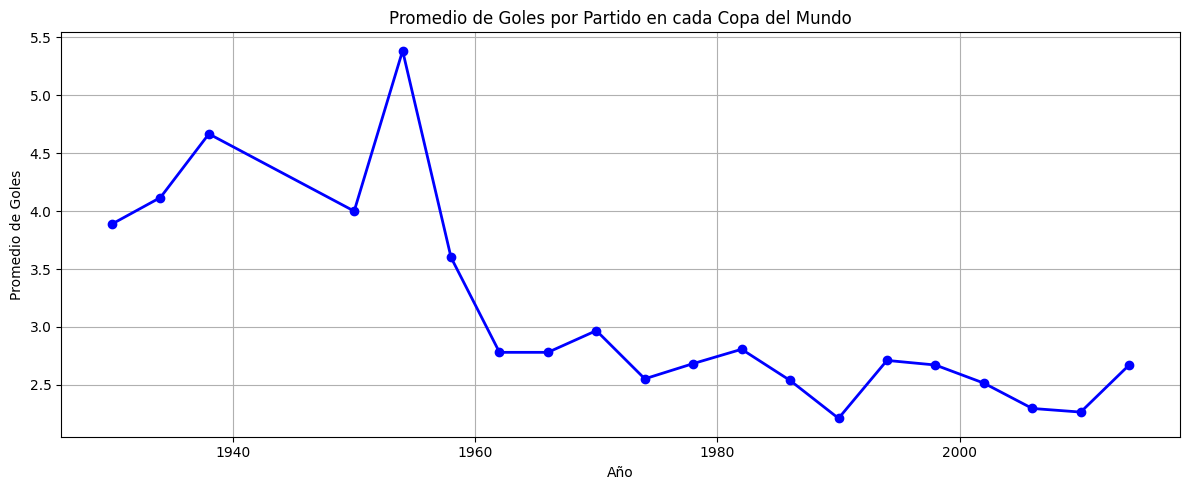

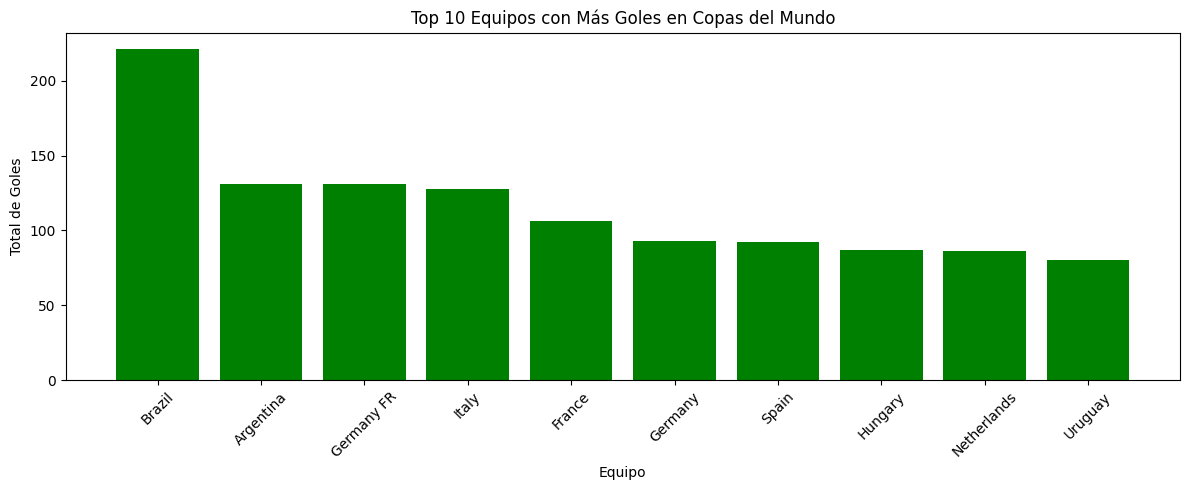

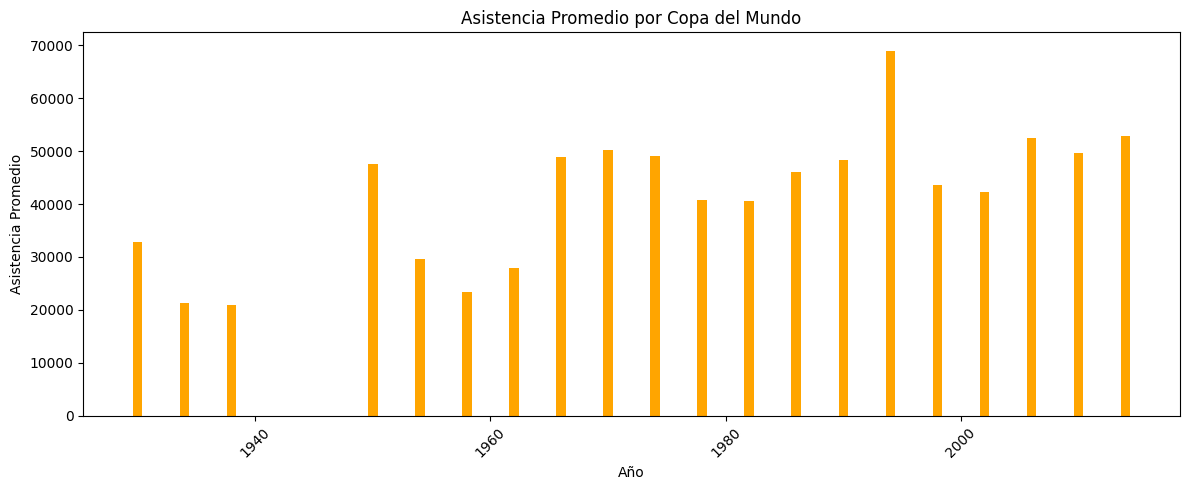

In [ ]:
import matplotlib.pyplot as plt
from pyspark.sql.functions import col, sum as spark_sum, avg, desc


goles_por_año = df_clean.groupBy('Año') \
    .agg(avg(col('goles_local') + col('goles_visitante'))
    .alias('promedio_goles')) \
    .orderBy('Año') \
    .toPandas()

plt.figure(figsize=(12, 5))
plt.plot(goles_por_año['Año'], goles_por_año['promedio_goles'],
         marker='o', color='blue', linewidth=2)
plt.title('Promedio de Goles por Partido en cada Copa del Mundo')
plt.xlabel('Año')
plt.ylabel('Promedio de Goles')
plt.grid(True)
plt.tight_layout()
plt.show()


goles_como_local = df_clean.groupBy('Local') \
    .agg(spark_sum('goles_local').alias('goles'))

goles_como_visitante = df_clean.groupBy('Visitante') \
    .agg(spark_sum('goles_visitante').alias('goles')) \
    .withColumnRenamed('Visitante', 'Local')

goles_totales = goles_como_local.union(goles_como_visitante) \
    .groupBy('Local') \
    .agg(spark_sum('goles').alias('total_goles')) \
    .orderBy(desc('total_goles'))

top10 = goles_totales.limit(10).toPandas()

plt.figure(figsize=(12, 5))
plt.bar(top10['Local'], top10['total_goles'], color='green')
plt.title('Top 10 Equipos con Más Goles en Copas del Mundo')
plt.xlabel('Equipo')
plt.ylabel('Total de Goles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


asistencia = df_clean.groupBy('Año') \
    .agg(avg('Asistencia').alias('promedio_asistencia')) \
    .orderBy('Año') \
    .toPandas()

plt.figure(figsize=(12, 5))
plt.bar(asistencia['Año'], asistencia['promedio_asistencia'], color='orange')
plt.title('Asistencia Promedio por Copa del Mundo')
plt.xlabel('Año')
plt.ylabel('Asistencia Promedio')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
print('=== ANÁLISIS USANDO RDDs ===')

rdd = df.rdd

total = rdd.count()
print(f'Total de partidos: {total}')


rdd_limpio = rdd.filter(lambda row:
    row['Year'] is not None and
    row['HomeTeamGoals'] is not None and
    row['AwayTeamGoals'] is not None
)


goles_rdd = rdd_limpio.map(lambda row: (
    int(row['Year']),
    int(row['HomeTeamGoals']) + int(row['AwayTeamGoals'])
))

goles_por_año_rdd = goles_rdd.reduceByKey(lambda a, b: a + b)

print('\nGoles totales por año (RDD):')
resultados = sorted(goles_por_año_rdd.collect())
for año, goles in resultados:
    print(f'  {año}: {goles} goles')

partidos_goleadores = rdd_limpio.filter(lambda row:
    int(row['HomeTeamGoals']) + int(row['AwayTeamGoals']) > 5
)
print(f'\nPartidos con más de 5 goles: {partidos_goleadores.count()}')


print('\nEjemplos de partidos goleadores:')
for p in partidos_goleadores.take(3):
    print(f'  {p["Year"]}: {p["HomeTeamName"]} {p["HomeTeamGoals"]} - {p["AwayTeamGoals"]} {p["AwayTeamName"]}')

=== ANÁLISIS USANDO RDDs ===
Total de partidos: 836

Goles totales por año (RDD):
  1930: 70 goles
  1934: 70 goles
  1938: 84 goles
  1950: 88 goles
  1954: 140 goles
  1958: 126 goles
  1962: 89 goles
  1966: 89 goles
  1970: 95 goles
  1974: 97 goles
  1978: 102 goles
  1982: 146 goles
  1986: 132 goles
  1990: 115 goles
  1994: 141 goles
  1998: 171 goles
  2002: 161 goles
  2006: 147 goles
  2010: 145 goles
  2014: 171 goles

Partidos con más de 5 goles: 73

Ejemplos de partidos goleadores:
  1930: Argentina 6 - 3 Mexico
  1930: Argentina 6 - 1 USA
  1930: Uruguay 6 - 1 Yugoslavia


In [1]:
!pip install kafka-python -q
!pip install pyspark -q
print("Dependencias instaladas ✅")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 326.1/326.1 kB 2.3 MB/s eta 0:00:00
Dependencias instaladas ✅


In [2]:
import threading
import time
import json
import random
from datetime import datetime


equipos = ['Brasil', 'Argentina', 'Alemania', 'Francia', 'España',
           'Colombia', 'Uruguay', 'Portugal', 'Italia', 'Inglaterra']

from queue import Queue
cola_mensajes = Queue()

def generar_partido():
    """Genera un partido aleatorio simulando datos en tiempo real"""
    local = random.choice(equipos)
    visitante = random.choice([e for e in equipos if e != local])
    return {
        'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'local': local,
        'visitante': visitante,
        'goles_local': random.randint(0, 5),
        'goles_visitante': random.randint(0, 5),
        'estadio': random.choice(['Maracaná', 'Bernabéu', 'Wembley', 'Camp Nou']),
        'asistencia': random.randint(30000, 90000)
    }

def producer(num_mensajes=20):
    """Simula un producer de Kafka enviando partidos cada segundo"""
    print("🚀 Producer iniciado - Enviando datos en tiempo real...")
    for i in range(num_mensajes):
        partido = generar_partido()
        cola_mensajes.put(partido)
        print(f"📤 Enviado: {partido['local']} {partido['goles_local']} - {partido['goles_visitante']} {partido['visitante']}")
        time.sleep(1)
    print("✅ Producer finalizado")


hilo_producer = threading.Thread(target=producer, args=(20,))
hilo_producer.start()
print("Producer corriendo en background...")

🚀 Producer iniciado - Enviando datos en tiempo real...
📤 Enviado: Italia 5 - 4 Brasil
Producer corriendo en background...


In [3]:
import time
from pyspark.sql import SparkSession
from pyspark.sql.functions import col


spark = SparkSession.builder \
    .appName("KafkaSparkStreaming_Simulado") \
    .getOrCreate()

print("SparkSession creada ✅")
print("\n=== SPARK STREAMING - PROCESAMIENTO EN TIEMPO REAL ===")
print("Consumiendo datos del topic 'partidos'...\n")


time.sleep(3)


total_partidos = 0
total_goles = 0
victorias_local = 0
victorias_visitante = 0
empates = 0
datos_batch = []

print(f"{'='*60}")
print(f"{'MICRO-BATCH':<12} {'PARTIDO':<35} {'RESULTADO'}")
print(f"{'='*60}")

batch_num = 1
while not cola_mensajes.empty() or hilo_producer.is_alive():
    batch = []


    for _ in range(3):
        if not cola_mensajes.empty():
            batch.append(cola_mensajes.get())

    if batch:

        df_batch = spark.createDataFrame(batch)

        print(f"\n📊 Micro-batch #{batch_num} - {len(batch)} partido(s):")

        for partido in batch:
            total_partidos += 1
            goles = partido['goles_local'] + partido['goles_visitante']
            total_goles += goles

            if partido['goles_local'] > partido['goles_visitante']:
                resultado = "🏆 Gana Local"
                victorias_local += 1
            elif partido['goles_visitante'] > partido['goles_local']:
                resultado = "🏆 Gana Visitante"
                victorias_visitante += 1
            else:
                resultado = "🤝 Empate"
                empates += 1

            print(f"  ⚽ {partido['local']} {partido['goles_local']} - {partido['goles_visitante']} {partido['visitante']} | {resultado}")

        # Estadísticas del batch con Spark
        print(f"\n  📈 Estadísticas acumuladas:")
        print(f"     Total partidos procesados: {total_partidos}")
        print(f"     Total goles: {total_goles}")
        print(f"     Promedio goles/partido: {total_goles/total_partidos:.2f}")
        print(f"     Victorias local: {victorias_local} | Visitante: {victorias_visitante} | Empates: {empates}")

        datos_batch.extend(batch)
        batch_num += 1

    time.sleep(2)

print(f"\n{'='*60}")
print("✅ Streaming finalizado")

SparkSession creada ✅

=== SPARK STREAMING - PROCESAMIENTO EN TIEMPO REAL ===
Consumiendo datos del topic 'partidos'...

MICRO-BATCH  PARTIDO                             RESULTADO

📊 Micro-batch #1 - 3 partido(s):
  ⚽ Italia 5 - 4 Brasil | 🏆 Gana Local
  ⚽ Alemania 3 - 0 Colombia | 🏆 Gana Local
  ⚽ Francia 3 - 0 Colombia | 🏆 Gana Local

  📈 Estadísticas acumuladas:
     Total partidos procesados: 3
     Total goles: 15
     Promedio goles/partido: 5.00
     Victorias local: 3 | Visitante: 0 | Empates: 0

📊 Micro-batch #2 - 3 partido(s):
  ⚽ Colombia 4 - 0 Argentina | 🏆 Gana Local
  ⚽ Alemania 1 - 4 Inglaterra | 🏆 Gana Visitante
  ⚽ Francia 1 - 1 Argentina | 🤝 Empate

  📈 Estadísticas acumuladas:
     Total partidos procesados: 6
     Total goles: 26
     Promedio goles/partido: 4.33
     Victorias local: 4 | Visitante: 1 | Empates: 1

📊 Micro-batch #3 - 3 partido(s):
  ⚽ Brasil 3 - 3 Alemania | 🤝 Empate
  ⚽ Brasil 5 - 2 Argentina | 🏆 Gana Local
  ⚽ Brasil 2 - 2 Inglaterra | 🤝 Empate

 

In [4]:
print("=== ANÁLISIS FINAL DE DATOS EN TIEMPO REAL ===\n")

# Crear DataFrame con todos los datos procesados
df_streaming = spark.createDataFrame(datos_batch)

print("Schema de los datos procesados en tiempo real:")
df_streaming.printSchema()

print("\nTodos los partidos procesados:")
df_streaming.select('timestamp', 'local', 'goles_local',
                    'goles_visitante', 'visitante').show(truncate=False)

print("\nEquipo con más victorias como local:")
from pyspark.sql.functions import when, sum as spark_sum, desc

df_resultados = df_streaming.withColumn('victoria_local',
    when(col('goles_local') > col('goles_visitante'), 1).otherwise(0))

df_resultados.groupBy('local') \
    .agg(spark_sum('victoria_local').alias('victorias')) \
    .orderBy(desc('victorias')) \
    .show(5)

print("\nEstadio con mayor asistencia promedio:")
from pyspark.sql.functions import avg
df_streaming.groupBy('estadio') \
    .agg(avg('asistencia').alias('asistencia_promedio')) \
    .orderBy(desc('asistencia_promedio')) \
    .show()

print("\n✅ Análisis de datos en tiempo real completado exitosamente")

=== ANÁLISIS FINAL DE DATOS EN TIEMPO REAL ===

Schema de los datos procesados en tiempo real:
root
 |-- asistencia: long (nullable = true)
 |-- estadio: string (nullable = true)
 |-- goles_local: long (nullable = true)
 |-- goles_visitante: long (nullable = true)
 |-- local: string (nullable = true)
 |-- timestamp: string (nullable = true)
 |-- visitante: string (nullable = true)


Todos los partidos procesados:
+-------------------+----------+-----------+---------------+----------+
|timestamp          |local     |goles_local|goles_visitante|visitante |
+-------------------+----------+-----------+---------------+----------+
|2026-04-22 20:40:51|Italia    |5          |4              |Brasil    |
|2026-04-22 20:40:52|Alemania  |3          |0              |Colombia  |
|2026-04-22 20:40:53|Francia   |3          |0              |Colombia  |
|2026-04-22 20:40:54|Colombia  |4          |0              |Argentina |
|2026-04-22 20:40:55|Alemania  |1          |4              |Inglaterra|
|2026-0